# From data to comparison of policies

Monetary quantities are in units of $10^{-6}$ USD.

## 1. Load the configuration and one benchmark

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from dataclasses import replace
from cri.config import load_config

CONFIG = load_config(ROOT / "configs/default.toml")
CONFIG = replace(
    CONFIG, data_root=ROOT / "datasets", rewards_root=ROOT / "rewards"
)  # paths relative to the repository
print("environments:", [env.id for env in CONFIG.environments])
print("mechanism   :", CONFIG.mechanism)

environments: ['GSM8K-full', 'GPQA-full', 'AIME-full', 'GSM8K-ladder', 'GPQA-ladder', 'AIME-ladder', 'GSM8K-all', 'GPQA-all', 'AIME-all']
mechanism   : MechanismConfig(margin=0.25, token_cap=512, c_max=None, delta=0.05, gamma=0.0)


In [2]:
from cri.data import load_benchmark

BENCHMARK = "GSM8K"  # 'GSM8K' | 'GPQA' | 'AIME'
BASE_MODELS = CONFIG.rosters["full"]  # the nine base models
DATA = load_benchmark(
    ROOT / "datasets", BENCHMARK, BASE_MODELS, rewards_root=ROOT / "rewards"
)

print(
    f"{DATA.n_questions} questions x {DATA.samples_per_question} recorded generations per model"
)
print("models:", DATA.models)

1319 questions x 128 recorded generations per model
models: ['Llama-3-8B', 'Llama-3.1-8B', 'Llama-3.2-1B', 'Llama-3.2-3B', 'Qwen2-0.5B', 'Qwen2-1.5B', 'Qwen2-7B', 'Qwen2.5-3B', 'Qwen2.5-7B']


## 2. Inspect the raw data

Each question has 128 recorded generations per model: a correctness bit, an output token count, and a reward-model score, aligned one to one.

In [3]:
rec = DATA.records["Qwen2.5-3B"]
q = 0  # first question
print("question   :", DATA.qids[q])
print("correctness:", rec.correctness[q, :10], "...")
print("tokens     :", rec.num_tokens[q, :10], "...")
print("rewards    :", rec.rewards[q, :5].round(3), "...")
print(
    f"this model over the whole benchmark: mean correctness {rec.correctness.mean():.3f}, mean tokens {rec.num_tokens.mean():.1f}"
)

question   : gsm8k-1
correctness: [1 1 1 1 1 1 1 1 1 1] ...
tokens     : [312 348 258 301 347 248 326 296 198 263] ...
rewards    : [0.146 0.145 0.155 0.145 0.13 ] ...
this model over the whole benchmark: mean correctness 0.839, mean tokens 309.4


## 3. Each base model as a provider: quality and cost

Quality is the mean correctness over all recorded generations; cost is mean tokens times the per-token price deflated by the margin (price = (1 + margin) x cost).

In [4]:
from cri.pricing import MODEL_PRICE_PER_1M, unit_cost

MARGIN = CONFIG.mechanism.margin
print(f'{"model":14} {"price/1M":>9} {"quality":>8} {"cost":>7}')
for m in BASE_MODELS:
    r = DATA.records[m]
    print(
        f"{m:14} {MODEL_PRICE_PER_1M[m]:9.4f} {r.correctness.mean():8.3f} {r.num_tokens.mean() * unit_cost(m, MARGIN):7.1f}"
    )

model           price/1M  quality    cost
Llama-3-8B        0.1455    0.650    22.3
Llama-3.1-8B      0.1245    0.648    23.3
Llama-3.2-1B      0.1000    0.364    15.9
Llama-3.2-3B      0.0800    0.692    12.5
Qwen2-0.5B        0.1000    0.351    14.5
Qwen2-1.5B        0.1000    0.574    15.1
Qwen2-7B          0.2000    0.836    37.4
Qwen2.5-3B        0.0650    0.839    16.1
Qwen2.5-7B        0.1465    0.907    34.4


## 4. Best-of-N variants and the roster

A provider `model@N` serves N generations, keeps the one with the highest reward, and pays for all N. The shipped `ladder` roster is four base models at N = 1, 2 and 4; `full` is the nine base models and `all` every base model at every N.

In [5]:
from cri.variants import expected_quality, expected_cost, parse_variant

ROSTER = CONFIG.rosters["ladder"]
THETA = next(env.theta for env in CONFIG.environments if env.id == "GSM8K-ladder")

print(f"Theta = {THETA}")
print(f'{"provider":16} {"N":>2} {"quality":>8} {"cost":>7}')
for name in ROSTER:
    v = parse_variant(name)
    print(
        f"{name:16} {v.n:2d} {expected_quality(DATA.records[v.base], v.n):8.3f} "
        f"{expected_cost(DATA.records[v.base], v.n, MARGIN):7.1f}"
    )

Theta = 0.805
provider          N  quality    cost
Llama-3-8B        1    0.650    22.3
Llama-3-8B@2      2    0.669    44.7
Llama-3-8B@4      4    0.677    89.4
Llama-3.2-1B      1    0.364    15.9
Llama-3.2-1B@2    2    0.410    31.8
Llama-3.2-1B@4    4    0.440    63.6
Qwen2-1.5B        1    0.574    15.1
Qwen2-1.5B@2      2    0.652    30.3
Qwen2-1.5B@4      4    0.703    60.6
Qwen2.5-7B        1    0.907    34.4
Qwen2.5-7B@2      2    0.923    68.7
Qwen2.5-7B@4      4    0.930   137.5


## 5. Or build your own roster

Any list of base models and variants is a roster. $\Theta$ has to sit between two of its qualities and leave at least two providers qualified; the midpoints are the natural choices. To use it below, assign it to `ROSTER` and pick `THETA` here.

In [6]:
from cri.metrics import ground_truth

MY_ROSTER = [
    "Qwen2-1.5B",
    "Qwen2-1.5B@2",
    "Llama-3-8B",
    "Llama-3-8B@2",
    "Qwen2.5-7B",
    "Qwen2.5-7B@2",
]
qualities = sorted(
    expected_quality(DATA.records[parse_variant(m).base], parse_variant(m).n)
    for m in MY_ROSTER
)
print("qualities:", [round(x, 3) for x in qualities])
print("midpoints:", [round((a + b) / 2, 3) for a, b in zip(qualities, qualities[1:])])
my_truth = ground_truth(DATA, MY_ROSTER, 0.78, MARGIN)
print("at Theta = 0.78: Q =", my_truth.qualified, "  i* =", my_truth.istar)
# ROSTER, THETA = MY_ROSTER, 0.78

qualities: [0.574, 0.65, 0.652, 0.669, 0.907, 0.923]
midpoints: [0.612, 0.651, 0.66, 0.788, 0.915]
at Theta = 0.78: Q = ('Qwen2.5-7B', 'Qwen2.5-7B@2')   i* = Qwen2.5-7B


## 6. Where the roster sits among all candidates

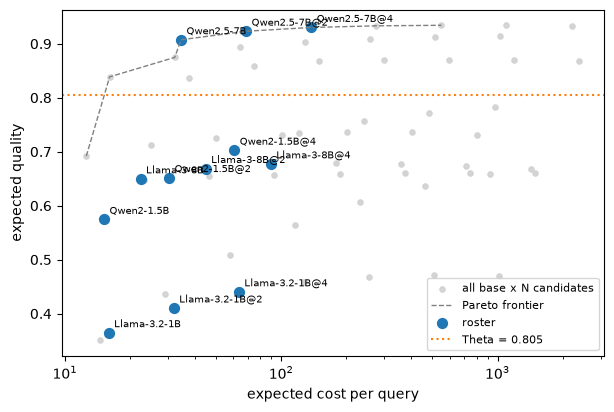

In [7]:
from cri.variants import VALID_N, landscape, pareto_frontier

every = landscape(DATA, BASE_MODELS, VALID_N, MARGIN)
front = pareto_frontier(every)
mine = [p for p in every if p.name in ROSTER]

plt.figure(figsize=(7, 4.5))
plt.scatter(
    [p.cost for p in every],
    [p.quality for p in every],
    s=14,
    color="lightgray",
    label="all base x N candidates",
)
plt.plot(
    [p.cost for p in front],
    [p.quality for p in front],
    "--",
    color="gray",
    lw=1,
    label="Pareto frontier",
)
plt.scatter(
    [p.cost for p in mine],
    [p.quality for p in mine],
    s=50,
    color="tab:blue",
    label="roster",
)
for p in mine:
    plt.annotate(
        p.name,
        (p.cost, p.quality),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
    )
plt.axhline(THETA, color="tab:orange", ls=":", label=f"Theta = {THETA}")
plt.xscale("log")
plt.xlabel("expected cost per query")
plt.ylabel("expected quality")
plt.legend(fontsize=8)
plt.show()

## 7. Ground truth: the qualified set, $i^*$ and the gaps

These are the paper's unknown parameters. They are used only for evaluation and oracles; the mechanism never sees them.

In [8]:
TRUTH = ground_truth(DATA, ROSTER, THETA, MARGIN)
print("qualified Q :", TRUTH.qualified)
print("i*          :", TRUTH.istar, f"(cost {TRUTH.c_star:.1f})")
print("c(2)        :", f"{TRUTH.c_second:.1f}", "   Delta =", f"{TRUTH.delta_gap:.1f}")
print("eps_j       :", {m: round(e, 3) for m, e in TRUTH.eps.items()})
print("Delta_j     :", {m: round(d, 1) for m, d in TRUTH.delta_j.items()})
print("trap        :", TRUTH.trap, f"(cheapest overall is {TRUTH.cheapest_overall})")

qualified Q : ('Qwen2.5-7B', 'Qwen2.5-7B@2', 'Qwen2.5-7B@4')
i*          : Qwen2.5-7B (cost 34.4)
c(2)        : 68.7    Delta = 34.4
eps_j       : {'Llama-3-8B': 0.155, 'Llama-3-8B@2': 0.136, 'Llama-3-8B@4': 0.128, 'Llama-3.2-1B': 0.441, 'Llama-3.2-1B@2': 0.395, 'Llama-3.2-1B@4': 0.365, 'Qwen2-1.5B': 0.231, 'Qwen2-1.5B@2': 0.153, 'Qwen2-1.5B@4': 0.102}
Delta_j     : {'Qwen2.5-7B@2': 34.4, 'Qwen2.5-7B@4': 103.1}
trap        : True (cheapest overall is Qwen2-1.5B)


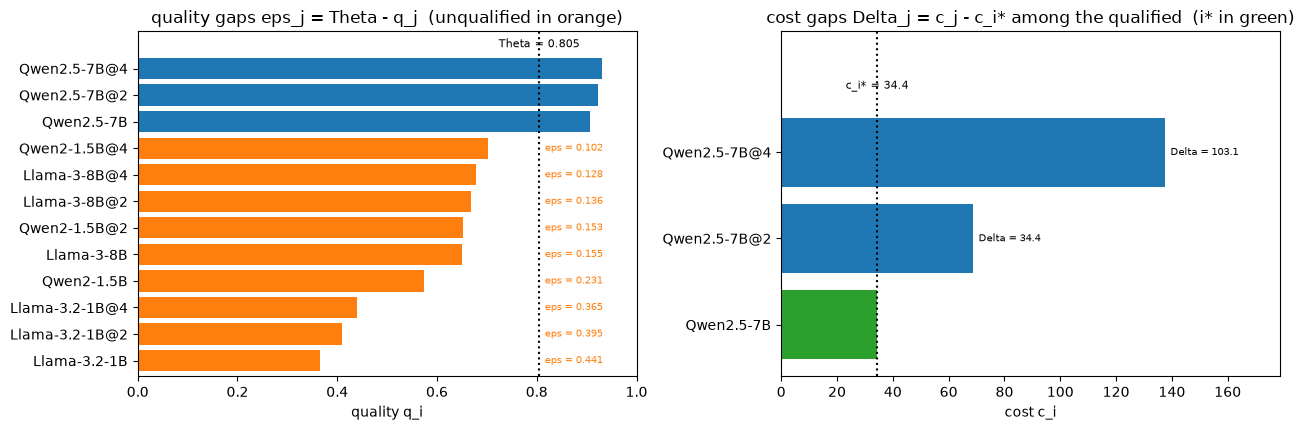

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# Left: every provider's quality against Theta; the gap of an unqualified provider is eps_j.
by_quality = sorted(ROSTER, key=lambda m: TRUTH.q[m])
ax1.barh(
    by_quality,
    [TRUTH.q[m] for m in by_quality],
    color=["tab:blue" if m in TRUTH.qualified else "tab:orange" for m in by_quality],
)
ax1.axvline(THETA, color="k", ls=":")
ax1.set_ylim(-0.6, len(by_quality) + 0.4)
ax1.text(
    THETA,
    len(by_quality) - 0.3,
    f"Theta = {THETA}",
    ha="center",
    va="bottom",
    fontsize=8,
)
for m in TRUTH.eps:
    ax1.annotate(
        f"eps = {TRUTH.eps[m]:.3f}",
        (THETA, by_quality.index(m)),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=7,
        color="tab:orange",
    )
ax1.set_xlim(0, 1)
ax1.set_xlabel("quality q_i")
ax1.set_title("quality gaps eps_j = Theta - q_j  (unqualified in orange)")

# Right: the qualified providers' costs against c_i*; the gap of each other one is Delta_j.
by_cost = sorted(TRUTH.qualified, key=lambda m: TRUTH.c[m])
ax2.barh(
    by_cost,
    [TRUTH.c[m] for m in by_cost],
    color=["tab:green" if m == TRUTH.istar else "tab:blue" for m in by_cost],
)
ax2.axvline(TRUTH.c_star, color="k", ls=":")
ax2.set_ylim(-0.6, len(by_cost) + 0.4)
ax2.text(
    TRUTH.c_star,
    len(by_cost) - 0.3,
    f"c_i* = {TRUTH.c_star:.1f}",
    ha="center",
    va="bottom",
    fontsize=8,
)
for m in TRUTH.delta_j:
    ax2.annotate(
        f"Delta = {TRUTH.delta_j[m]:.1f}",
        (TRUTH.c[m], by_cost.index(m)),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=7,
    )
ax2.set_xlim(0, 1.3 * max(TRUTH.c[m] for m in by_cost))
ax2.set_xlabel("cost c_i")
ax2.set_title("cost gaps Delta_j = c_j - c_i* among the qualified  (i* in green)")
plt.tight_layout()
plt.show()

## 8. The public constants: $C_{max}$, $\delta$, $\gamma$ and the radii

$C_{max}$ is pinned to the price scale (token cap x the largest N x price on the roster). The radius $\rho(m)$ shrinks with the selection count $m$ and is what the mechanism subtracts from a bid.

In [10]:
from cri.confidence import Radii
from cri.pricing import pinned_c_max

RADII = Radii(
    n=len(ROSTER),
    delta=CONFIG.mechanism.delta,
    c_max=pinned_c_max(ROSTER, CONFIG.mechanism.token_cap),
    gamma=CONFIG.mechanism.gamma,
)
print(RADII)
for m in (1, 10, 100, 1000):
    print(f"m = {m:4d}:  beta = {RADII.beta(m):.3f}   rho = {RADII.rho(m):7.1f}")

Radii(n=12, delta=0.05, c_max=300.032, gamma=0.0)
m =    1:  beta = 1.919   rho =   575.7
m =   10:  beta = 0.774   rho =   232.1
m =  100:  beta = 0.288   rho =    86.4
m = 1000:  beta = 0.103   rho =    30.9


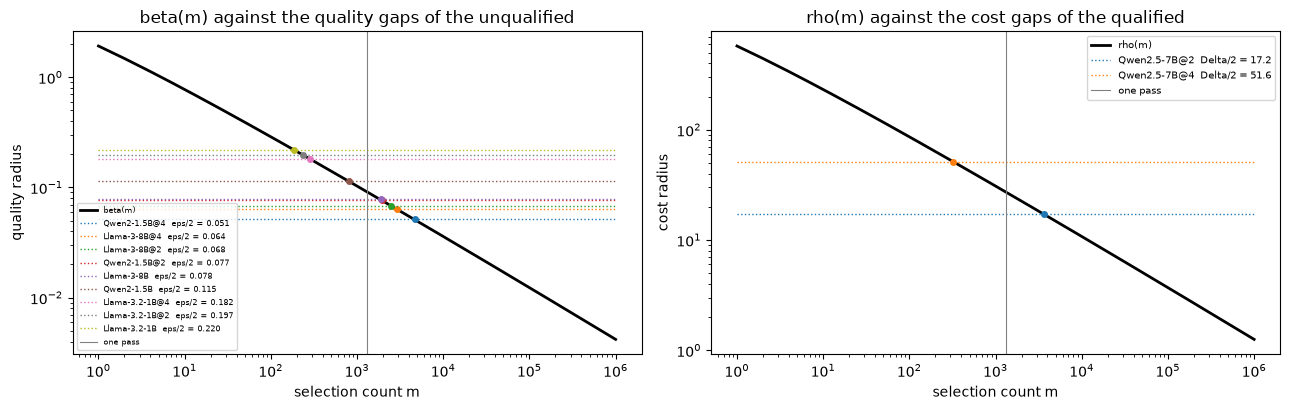

In [11]:
# The radii against the gaps they have to beat. On the good event an unqualified provider is
# eliminated once beta(m) < eps_j / 2, and a qualified competitor stops winning once
# rho(m) < Delta_j / 2; the crossing points are (up to constants) the M(eps_j) and L(Delta_j) counts.
ms = np.unique(np.logspace(0, 6, 400).astype(int))
beta = np.array([RADII.beta(int(m)) for m in ms])
rho = np.array([RADII.rho(int(m)) for m in ms])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
ax1.plot(ms, beta, color="k", lw=2, label="beta(m)")
for m_name, eps in sorted(TRUTH.eps.items(), key=lambda kv: kv[1]):
    (line,) = ax1.plot(
        ms,
        np.full_like(beta, eps / 2),
        ls=":",
        lw=1,
        label=f"{m_name}  eps/2 = {eps / 2:.3f}",
    )
    cross = ms[np.argmax(beta < eps / 2)]
    ax1.plot(cross, eps / 2, "o", color=line.get_color(), ms=4)
ax1.axvline(DATA.n_questions, color="gray", lw=0.8, label="one pass")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("selection count m")
ax1.set_ylabel("quality radius")
ax1.set_title("beta(m) against the quality gaps of the unqualified")
ax1.legend(fontsize=6)

ax2.plot(ms, rho, color="k", lw=2, label="rho(m)")
for m_name, gap in sorted(TRUTH.delta_j.items(), key=lambda kv: kv[1]):
    (line,) = ax2.plot(
        ms,
        np.full_like(rho, gap / 2),
        ls=":",
        lw=1,
        label=f"{m_name}  Delta/2 = {gap / 2:.1f}",
    )
    cross = ms[np.argmax(rho < gap / 2)]
    ax2.plot(cross, gap / 2, "o", color=line.get_color(), ms=4)
ax2.axvline(DATA.n_questions, color="gray", lw=0.8, label="one pass")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("selection count m")
ax2.set_ylabel("cost radius")
ax2.set_title("rho(m) against the cost gaps of the qualified")
ax2.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 9. The theory's numbers for this environment

In [12]:
from cri.metrics import theory_constants

TC = theory_constants(TRUTH, RADII, stream=DATA.n_questions)
print(
    f"sum M(eps_j) = {TC.sum_M:,}   sum L(Delta_j) = {TC.sum_L:,}   B_id = {TC.B_id:,}"
)
print(
    f"the recovery corollary needs T > n + 2 B_id = {TC.need:,}; one pass has {DATA.n_questions:,} rounds -> reachable: {TC.reachable}"
)

sum M(eps_j) = 23,132   sum L(Delta_j) = 6,012   B_id = 29,144
the recovery corollary needs T > n + 2 B_id = 58,300; one pass has 1,319 rounds -> reachable: False


## 10. The nine shipped environments at a glance

`prepare_environment` loads a configured environment and its ground truth the same way the command-line runner does.

In [13]:
from cri.experiment import prepare_environment

print(
    f'{"environment":12} {"n":>2} {"T":>5} {"Theta":>7} {"|Q|":>3} {"i*":16} {"Delta":>7} {"C_max":>7} {"B_id":>10}  n+2B_id reachable'
)
for env in CONFIG.environments:
    data, truth, radii = prepare_environment(CONFIG, env)
    tc = theory_constants(truth, radii, stream=data.n_questions)
    print(
        f"{env.id:12} {len(truth.roster):2d} {env.t_max:5d} {env.theta:7.4f} {len(truth.qualified):3d} {truth.istar:16} "
        f"{truth.delta_gap:7.1f} {radii.c_max:7.1f} {tc.B_id:10,}  {tc.reachable}"
    )

environment   n     T   Theta |Q| i*                 Delta   C_max       B_id  n+2B_id reachable
GSM8K-full    9  1319  0.7640   3 Qwen2.5-3B          18.3   102.4     31,760  False
GPQA-full     9   546  0.0790   8 Qwen2-1.5B          10.6   102.4    137,145  False
AIME-full     9   933  0.0300   3 Llama-3.2-3B        19.7   102.4  3,163,062  False
GSM8K-ladder 12  1319  0.8050   3 Qwen2.5-7B          34.4   300.0     29,144  False
GPQA-ladder  12   545  0.2396   4 Llama-3-8B          37.1   300.0  1,216,456  False
AIME-ladder  12   933  0.0189   4 Qwen2.5-7B          59.7   300.0 46,719,886  False
GSM8K-all    63  1319  0.8094  21 Qwen2.5-3B          16.1  6553.6 61,422,650  False
GPQA-all     63   545  0.2650  23 Llama-3-8B@2        74.2  6553.6 15,420,710  False
AIME-all     63   933  0.0470  18 Llama-3.2-3B        30.0  6553.6 55,437,966  False


## 11. One episode of the mechanism

Initialization selects every provider once at $C_{max}$; then each round scores the standing bids, selects the lowest score among the eligible, prices the winner before revealing anything, and lets the winner re-bid. `full_log=True` also keeps every provider's bid, score, quality UCB and eligibility at every round.

In [14]:
from cri.estimators import EstimatorConfig
from cri.simulate import simulate_episode

EP = simulate_episode(
    DATA,
    ROSTER,
    theta=THETA,
    radii=RADII,
    estimator=EstimatorConfig("empirical_mean"),
    margin=MARGIN,
    t_max=DATA.n_questions,
    seed=0,
    full_log=True,
)
print(
    EP.termination, "after", EP.rounds, "rounds; initialization order:", EP.init_order
)
print(EP.platform)

t_max after 1319 rounds; initialization order: ('Qwen2-1.5B', 'Qwen2-1.5B@4', 'Llama-3.2-1B', 'Qwen2.5-7B@4', 'Qwen2.5-7B@2', 'Llama-3.2-1B@2', 'Qwen2-1.5B@2', 'Llama-3-8B@4', 'Qwen2.5-7B', 'Llama-3-8B', 'Llama-3-8B@2', 'Llama-3.2-1B@4')
PlatformState(providers=mappingproxy({'Llama-3-8B': PlatformProvider(model='Llama-3-8B', m=300, correct_sum=191, bid=22.074096), 'Llama-3-8B@2': PlatformProvider(model='Llama-3-8B@2', m=130, correct_sum=95, bid=45.749676923076926), 'Llama-3-8B@4': PlatformProvider(model='Llama-3-8B@4', m=39, correct_sum=24, bid=99.78763076923077), 'Llama-3.2-1B': PlatformProvider(model='Llama-3.2-1B', m=37, correct_sum=13, bid=14.443243243243248), 'Llama-3.2-1B@2': PlatformProvider(model='Llama-3.2-1B@2', m=37, correct_sum=13, bid=32.95567567567567), 'Llama-3.2-1B@4': PlatformProvider(model='Llama-3.2-1B@4', m=27, correct_sum=8, bid=61.14666666666667), 'Qwen2-1.5B': PlatformProvider(model='Qwen2-1.5B', m=167, correct_sum=96, bid=14.91784431137725), 'Qwen2-1.5B@2': Plat

## 12. Look at the round log

In [15]:
LOG = EP.log.columns()
print(
    f'{"t":>4} {"phase":5} {"winner":16} {"m":>3} {"bid":>7} {"score":>8} {"payment":>8} {"cost":>7} Y'
)
for i in list(range(8)) + list(range(EP.rounds - 4, EP.rounds)):
    print(
        f'{LOG["t"][i]:4} {LOG["phase"][i]:5} {LOG["winner"][i]:16} {LOG["m_winner"][i]:3} {LOG["bid_winner"][i]:7.1f} '
        f'{LOG["score_winner"][i]:8.1f} {LOG["payment"][i]:8.1f} {LOG["cost"][i]:7.1f} {LOG["correctness"][i]}'
    )

   t phase winner             m     bid    score  payment    cost Y
   1 init  Qwen2-1.5B         0     nan      nan    300.0    11.0 1
   2 init  Qwen2-1.5B@4       0     nan      nan    300.0   108.5 1
   3 init  Llama-3.2-1B       0     nan      nan    300.0    10.3 1
   4 init  Qwen2.5-7B@4       0     nan      nan    300.0   160.1 1
   5 init  Qwen2.5-7B@2       0     nan      nan    300.0    53.8 1
   6 init  Llama-3.2-1B@2     0     nan      nan    300.0    44.7 1
   7 init  Qwen2-1.5B@2       0     nan      nan    300.0    33.9 0
   8 init  Llama-3-8B@4       0     nan      nan    300.0    98.1 1
1316 main  Llama-3-8B       297    22.0    -31.3     22.0    17.9 1
1317 main  Qwen2-1.5B@2     219    29.8    -31.3     29.8    21.5 1
1318 main  Llama-3-8B       298    22.0    -31.3     22.0    14.7 1
1319 main  Llama-3-8B       299    21.9    -31.2     22.0    59.6 0


## 13. One round by hand

The platform state at the end of the episode, scored as the next round would be: the eligible set, each provider's score and quality UCB, the winner, and each provider's critical payment. The winner is the one provider whose bid is below its own critical payment (the threshold lemma); everyone else would have to bid less than its payment to win.

In [16]:
from cri.mechanism import critical_payment, select

P = EP.platform  # state after the last round
sel = select(P, tie_u=0.5)
print(
    f'{"provider":16} {"m":>4} {"bid":>7} {"score":>8} {"q_UCB":>6} {"eligible":>8} {"critical payment":>17}  bid < payment'
)
for name in ROSTER:
    p = P.providers[name]
    if name in sel.eligible:
        pay = critical_payment(P, name, sel.eligible)
        print(
            f'{name:16} {p.m:4d} {p.bid:7.1f} {P.score(name):8.1f} {P.q_ucb(name):6.3f} {"yes":>8} {pay:17.1f}  {str(p.bid < pay):5}',
            "<- winner" if name == sel.winner else "",
        )
    else:
        print(
            f'{name:16} {p.m:4d} {p.bid:7.1f} {P.score(name):8.1f} {P.q_ucb(name):6.3f} {"no":>8}'
        )

provider            m     bid    score  q_UCB eligible  critical payment  bid < payment
Llama-3-8B        300    22.1    -31.0  0.814      yes              21.9  False 
Llama-3-8B@2      130    45.7    -31.2  0.987      yes              45.8  True  <- winner
Llama-3-8B@4       39    99.8    -30.4  1.000      yes              99.0  False 
Llama-3.2-1B       37    14.4   -118.8  0.795       no
Llama-3.2-1B@2     37    33.0   -100.3  0.795       no
Llama-3.2-1B@4     27    61.1    -91.4  0.805       no
Qwen2-1.5B        167    14.9    -54.0  0.804       no
Qwen2-1.5B@2      220    29.8    -31.2  0.835      yes              29.7  False 
Qwen2-1.5B@4       86    61.2    -31.0  1.000      yes              61.1  False 
Qwen2.5-7B        182    35.1    -31.2  1.000      yes              35.1  False 
Qwen2.5-7B@2       73    68.5    -30.6  1.000      yes              68.0  False 
Qwen2.5-7B@4       21   139.6    -30.2  1.000      yes             138.6  False 


## 14. The metrics of that episode

In [17]:
from cri.metrics import evaluate

M = evaluate(EP.log, TRUTH, RADII)
print(
    f"accuracy {M.realized_accuracy:.3f}   total cost {M.total_cost:,.0f}   total payment {M.total_payment:,.0f}"
)
print(
    f"R_qual {M.quality_regret:.1f}   R_gen {M.generation_regret:,.0f}   E_pay {M.excess_payment:,.0f}"
)
print(f"i* share {M.istar_share:.3f}   selection counts {M.selection_counts}")
print(
    f"good event held: {M.good_event_holds}   max belief slack: {M.max_slack_ratio:.3f}"
)
print(
    f"rounds not selecting i*: {M.non_istar_rounds} (the identification bound allows at most B_id = {TC.B_id:,} after initialization)"
)
print(
    f"i* is the most-selected provider: {M.argmax_is_istar};   recovery certificate (m_j > B_id + 1 only for i*): {M.identifies_istar}"
)

accuracy 0.673   total cost 48,500   total payment 52,279
R_qual 191.1   R_gen 11,206   E_pay 5,678
i* share 0.138   selection counts {'Llama-3-8B': 300, 'Llama-3-8B@2': 130, 'Llama-3-8B@4': 39, 'Llama-3.2-1B': 37, 'Llama-3.2-1B@2': 37, 'Llama-3.2-1B@4': 27, 'Qwen2-1.5B': 167, 'Qwen2-1.5B@2': 220, 'Qwen2-1.5B@4': 86, 'Qwen2.5-7B': 182, 'Qwen2.5-7B@2': 73, 'Qwen2.5-7B@4': 21}
good event held: True   max belief slack: 0.000
rounds not selecting i*: 1137 (the identification bound allows at most B_id = 29,144 after initialization)
i* is the most-selected provider: False;   recovery certificate (m_j > B_id + 1 only for i*): False


## 15. Selection share over time

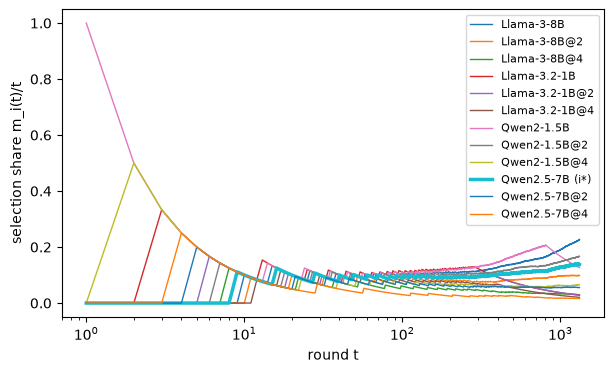

In [18]:
t = LOG["t"].astype(float)
plt.figure(figsize=(7, 4))
for name in ROSTER:
    share = np.cumsum(LOG["winner"] == name) / t
    plt.plot(
        t,
        share,
        lw=2.5 if name == TRUTH.istar else 1,
        label=name + (" (i*)" if name == TRUTH.istar else ""),
    )
plt.xscale("log")
plt.xlabel("round t")
plt.ylabel("selection share m_i(t)/t")
plt.legend(fontsize=8)
plt.show()

## 16. What the platform believed: quality UCB and eligibility

A provider is eligible while $\min\{1, \hat q_i + \beta(m_i)\} \ge \Theta$. Unqualified providers drop out once their UCB falls below the line; that is the quality-elimination lemma at work.

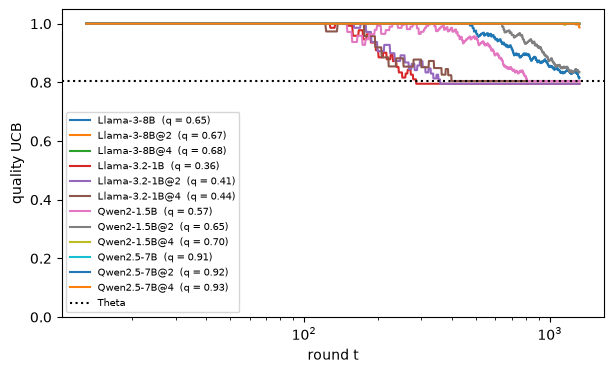

eligible at the end: ['Llama-3-8B', 'Llama-3-8B@2', 'Llama-3-8B@4', 'Qwen2-1.5B@2', 'Qwen2-1.5B@4', 'Qwen2.5-7B', 'Qwen2.5-7B@2', 'Qwen2.5-7B@4']
first round ineligible: {'Llama-3.2-1B': 286, 'Llama-3.2-1B@2': 358, 'Llama-3.2-1B@4': 398, 'Qwen2-1.5B': 809}


In [19]:
F = EP.full_log  # arrays of shape (main rounds, providers), in ROSTER order
t_main = np.arange(len(ROSTER) + 1, EP.rounds + 1)
plt.figure(figsize=(7, 4))
for j, name in enumerate(ROSTER):
    plt.plot(t_main, F["q_ucb"][:, j], label=f"{name}  (q = {TRUTH.q[name]:.2f})")
plt.axhline(THETA, color="k", ls=":", label="Theta")
plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("round t")
plt.ylabel("quality UCB")
plt.legend(fontsize=7)
plt.show()

eligible_end = [name for j, name in enumerate(ROSTER) if F["eligible"][-1, j]]
dropped = {
    name: int(t_main[np.argmin(F["eligible"][:, j])])
    for j, name in enumerate(ROSTER)
    if not F["eligible"][-1, j]
}
print("eligible at the end:", eligible_end)
print("first round ineligible:", dropped)

## 17. Bids, payments and the envelope

The score-bounds lemma says a bid stays within $\rho(m)$ of the true cost on the good event. The payment lemma bounds each payment between $c_i - \rho(m_i)$ and $c^{(2)} + \rho(m_i)$; the excess payment $E^{pay}_T$ sums what is paid above $c^{(2)}$, and the provider payoff is what each provider netted.

|bid - c_i| / rho(m) over all main rounds: max 0.113   (at most 1 on the good event)


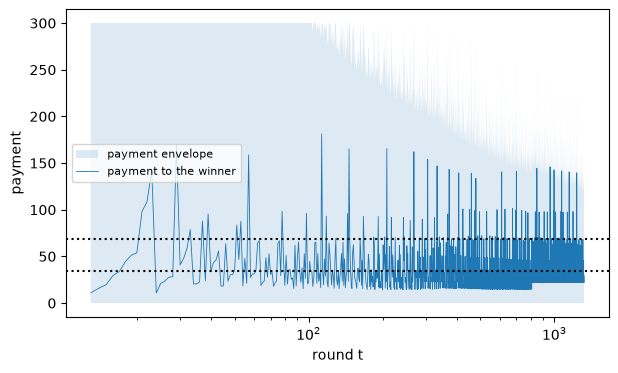

E_pay = 5,678  (initialization 2,775 + after 2,903)
provider payoff sum(pi - C): {'Llama-3-8B': 377, 'Llama-3-8B@2': 414, 'Llama-3-8B@4': 79, 'Llama-3.2-1B': 335, 'Llama-3.2-1B@2': 362, 'Llama-3.2-1B@4': 28, 'Qwen2-1.5B': 417, 'Qwen2-1.5B@2': 174, 'Qwen2-1.5B@4': 670, 'Qwen2.5-7B': 230, 'Qwen2.5-7B@2': 330, 'Qwen2.5-7B@4': 364}
rounds where the critical payment would pay less than the bid: 0   (0 for the mechanism: the threshold lemma)


In [20]:
main = LOG["phase"] == "main"
rho = np.array([RADII.rho(int(m)) for m in LOG["m_winner"][main]])
true_cost = np.array([TRUTH.c[w] for w in LOG["winner"][main]])
bid_error = (LOG["bid_winner"][main] - true_cost) / rho
print(
    f"|bid - c_i| / rho(m) over all main rounds: max {np.abs(bid_error).max():.3f}   (at most 1 on the good event)"
)

t_pay, pay = LOG["t"][main], LOG["payment"][main]
lower, upper = np.maximum(0.0, true_cost - rho), np.minimum(
    RADII.c_max, TRUTH.c_second + rho
)
plt.figure(figsize=(7, 4))
plt.fill_between(t_pay, lower, upper, alpha=0.15, label="payment envelope")
plt.plot(t_pay, pay, lw=0.6, label="payment to the winner")
plt.axhline(TRUTH.c_star, color="k", ls=":")
plt.axhline(TRUTH.c_second, color="k", ls=":")
plt.xscale("log")
plt.xlabel("round t")
plt.ylabel("payment")
plt.legend(fontsize=8)
plt.show()

print(
    f"E_pay = {M.excess_payment:,.0f}  (initialization {M.excess_payment_init:,.0f} + after {M.excess_payment_post:,.0f})"
)
print(
    "provider payoff sum(pi - C):", {m: round(v) for m, v in M.provider_payoff.items()}
)
print(
    f"rounds where the critical payment would pay less than the bid: {M.critical_below_bid_rounds}   (0 for the mechanism: the threshold lemma)"
)

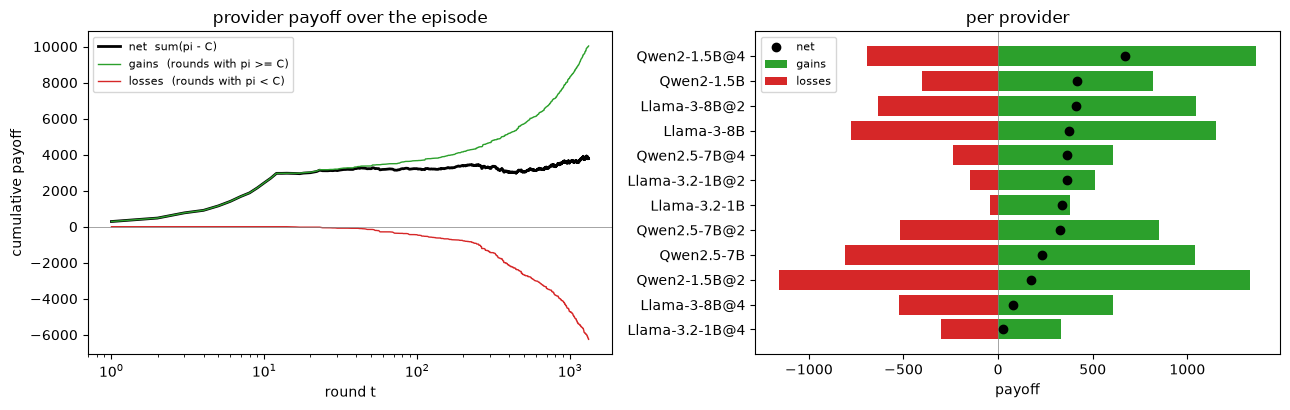

rounds with a negative payoff: 535 of 1319   gained 10,034   lost 6,255   net 3,779


In [21]:
# Provider payoff pi - C round by round: negative whenever the realized cost exceeds the payment.
payoff = LOG["payment"].astype(float) - LOG["cost"]
gain, loss = np.maximum(payoff, 0.0), np.minimum(payoff, 0.0)
t_all = LOG["t"].astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
# Left: the running sum over every round, split into what was gained and what was lost.
ax1.plot(t_all, np.cumsum(payoff), color="k", lw=2, label="net  sum(pi - C)")
ax1.plot(
    t_all,
    np.cumsum(gain),
    color="tab:green",
    lw=1,
    label="gains  (rounds with pi >= C)",
)
ax1.plot(
    t_all, np.cumsum(loss), color="tab:red", lw=1, label="losses  (rounds with pi < C)"
)
ax1.axhline(0, color="gray", lw=0.5)
ax1.set_xscale("log")
ax1.set_xlabel("round t")
ax1.set_ylabel("cumulative payoff")
ax1.set_title("provider payoff over the episode")
ax1.legend(fontsize=8)

# Right: the same split per provider, net as a marker.
by_payoff = sorted(ROSTER, key=lambda m: M.provider_payoff[m])
pos = [gain[LOG["winner"] == m].sum() for m in by_payoff]
neg = [loss[LOG["winner"] == m].sum() for m in by_payoff]
ax2.barh(by_payoff, pos, color="tab:green", label="gains")
ax2.barh(by_payoff, neg, color="tab:red", label="losses")
ax2.scatter(
    [M.provider_payoff[m] for m in by_payoff],
    by_payoff,
    color="k",
    zorder=3,
    label="net",
)
ax2.axvline(0, color="gray", lw=0.5)
ax2.set_xlabel("payoff")
ax2.set_title("per provider")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(
    f"rounds with a negative payoff: {int((payoff < 0).sum())} of {len(payoff)}   "
    f"gained {gain.sum():,.0f}   lost {-loss.sum():,.0f}   net {payoff.sum():,.0f}"
)

## 18. The same episode under the baselines

Same seed, so every policy faces the same questions and the same recorded generations. Only arms whose winner is the score-argmin of their candidate set carry the paper's payment; the others run unpaid.

In [22]:
from cri.baselines import PAYMENT_APPLIES, make_policy, make_payment_rule

POLICIES = [
    "mechanism",
    "uniform_random",
    "cheapest_bid",
    "quality_greedy",
    "oracle_cheapest_qualified",
    "no_quality_filter",
    "greedy_cheapest_qualified",
]

print(
    f'{"policy":26} {"accuracy":>8} {"cost":>8} {"R_qual":>7} {"R_gen":>8} {"i* share":>8}'
)
for name in POLICIES:
    ep = simulate_episode(
        DATA,
        ROSTER,
        theta=THETA,
        radii=RADII,
        estimator=EstimatorConfig("empirical_mean"),
        margin=MARGIN,
        t_max=DATA.n_questions,
        seed=0,
        policy=make_policy(name, TRUTH),
        payment_rule=make_payment_rule("critical" if name in PAYMENT_APPLIES else None),
    )
    m = evaluate(ep.log, TRUTH, RADII)
    print(
        f"{name:26} {m.realized_accuracy:8.3f} {m.total_cost:8,.0f} {m.quality_regret:7.1f} {m.generation_regret:8,.0f} {m.istar_share:8.3f}"
    )

policy                     accuracy     cost  R_qual    R_gen i* share
mechanism                     0.673   48,500   191.1   11,206    0.138
uniform_random                0.645   67,877   227.7   28,906    0.103
cheapest_bid                  0.371   21,411   576.3      258    0.001
quality_greedy                0.819   91,745    78.0   49,472    0.221
oracle_cheapest_qualified     0.902   45,674     2.1      258    0.992
no_quality_filter             0.582   44,084   292.4    9,631    0.091
greedy_cheapest_qualified     0.748   36,472   135.1      288    0.512


## 19. Average over repetitions

Each repetition redraws the question order and the generations; the policies inside one repetition still share them.

In [23]:
REPS = 5
results = {name: [] for name in POLICIES}
for rep in range(REPS):
    for name in POLICIES:
        ep = simulate_episode(
            DATA,
            ROSTER,
            theta=THETA,
            radii=RADII,
            estimator=EstimatorConfig("empirical_mean"),
            margin=MARGIN,
            t_max=DATA.n_questions,
            seed=rep,
            repetition=rep,
            policy=make_policy(name, TRUTH),
            payment_rule=make_payment_rule(
                "critical" if name in PAYMENT_APPLIES else None
            ),
        )
        results[name].append(evaluate(ep.log, TRUTH, RADII))

print(f'{"policy":26} {"accuracy":>14} {"cost":>18} {"i* share":>14}  good event')
for name in POLICIES:
    acc = [m.realized_accuracy for m in results[name]]
    cost = [m.total_cost for m in results[name]]
    share = [m.istar_share for m in results[name]]
    print(
        f"{name:26} {np.mean(acc):7.3f} ± {np.std(acc):.3f} {np.mean(cost):10,.0f} ± {np.std(cost):6,.0f} "
        f"{np.mean(share):7.3f} ± {np.std(share):.3f}  {sum(m.good_event_holds for m in results[name])}/{REPS}"
    )

policy                           accuracy               cost       i* share  good event
mechanism                    0.676 ± 0.006     48,258 ±  1,147   0.132 ± 0.006  5/5
uniform_random               0.656 ± 0.012     67,052 ±  1,149   0.085 ± 0.012  5/5
cheapest_bid                 0.453 ± 0.102     21,012 ±    595   0.001 ± 0.000  5/5
quality_greedy               0.815 ± 0.008     89,580 ±  2,858   0.204 ± 0.026  5/5
oracle_cheapest_qualified    0.905 ± 0.002     45,577 ±     93   0.992 ± 0.000  5/5
no_quality_filter            0.599 ± 0.012     44,177 ±    119   0.089 ± 0.002  5/5
greedy_cheapest_qualified    0.722 ± 0.052     36,550 ±    880   0.357 ± 0.209  5/5


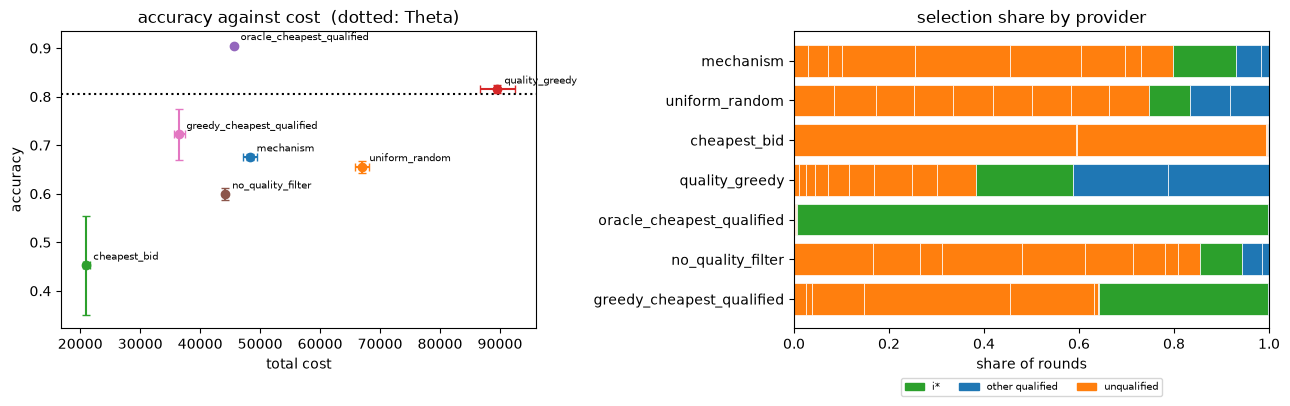

In [24]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
# Left: each policy in the cost-accuracy plane, with mean and standard deviation over repetitions.
for name in POLICIES:
    acc = [m.realized_accuracy for m in results[name]]
    cost = [m.total_cost for m in results[name]]
    ax1.errorbar(
        np.mean(cost),
        np.mean(acc),
        xerr=np.std(cost),
        yerr=np.std(acc),
        fmt="o",
        capsize=3,
    )
    ax1.annotate(
        name,
        (np.mean(cost), np.mean(acc)),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=7,
    )
ax1.axhline(THETA, color="k", ls=":")
ax1.set_xlabel("total cost")
ax1.set_ylabel("accuracy")
ax1.set_title("accuracy against cost  (dotted: Theta)")

# Right: where each policy's rounds went; i* green, other qualified blue, unqualified orange.
by_quality = sorted(ROSTER, key=lambda m: TRUTH.q[m])
left = np.zeros(len(POLICIES))
for m in by_quality:
    share = [
        np.mean([r.selection_counts[m] for r in results[name]]) / DATA.n_questions
        for name in POLICIES
    ]
    color = (
        "tab:green"
        if m == TRUTH.istar
        else "tab:blue" if m in TRUTH.qualified else "tab:orange"
    )
    ax2.barh(POLICIES, share, left=left, color=color, edgecolor="white", lw=0.5)
    left += share
ax2.invert_yaxis()
ax2.set_xlim(0, 1)
ax2.set_xlabel("share of rounds")
ax2.set_title("selection share by provider")
ax2.legend(
    handles=[
        Patch(color="tab:green", label="i*"),
        Patch(color="tab:blue", label="other qualified"),
        Patch(color="tab:orange", label="unqualified"),
    ],
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
)
plt.tight_layout()
plt.show()

## 20. The experiment ablations

Four labels change something other than the selection rule: the payment (`pay_your_bid`), the radii (`gamma_zero`), the cost stream (`independent_cost_stream`) or the providers' estimates (`biased_beliefs`). `resolve_arm` says exactly what each one changes.

In [25]:
from cri.experiment import resolve_arm

print(
    f'{"arm":24} {"payment":13} {"estimator":15} {"accuracy":>8} {"payment":>9} {"i* share":>8} {"slack":>6}'
)
for name in ("pay_your_bid", "gamma_zero", "independent_cost_stream", "biased_beliefs"):
    arm = resolve_arm(name, CONFIG, TRUTH, RADII)
    ep = simulate_episode(
        DATA,
        ROSTER,
        theta=THETA,
        radii=arm.radii,
        estimator=arm.estimator,
        margin=MARGIN,
        t_max=DATA.n_questions,
        seed=0,
        policy=make_policy(arm.policy_name, TRUTH),
        payment_rule=make_payment_rule(arm.payment_name),
        independent_costs=arm.independent_costs,
    )
    m = evaluate(ep.log, TRUTH, arm.radii)
    print(
        f"{name:24} {arm.payment_name:13} {arm.estimator.kind:15} {m.realized_accuracy:8.3f} {m.total_payment:9,.0f} "
        f"{m.istar_share:8.3f} {m.max_slack_ratio:6.2f}"
    )

arm                      payment       estimator       accuracy   payment i* share  slack
pay_your_bid             pay_your_bid  empirical_mean     0.673    51,744    0.138   0.00
gamma_zero               critical      empirical_mean     0.673    52,279    0.138   0.00
independent_cost_stream  critical      empirical_mean     0.659    51,038    0.132   0.00
biased_beliefs           critical      biased             0.673   150,314    0.138   1.41


## 21. Providers with beliefs: the shrinkage estimator and $\gamma$

A provider may shrink its empirical mean towards a prior. The belief-slack assumption then holds only if the platform widens its radius by $(1 + \gamma)$, and the smallest admissible $\gamma$ is computed, not guessed. The `biased` estimator breaks the assumption on purpose: its slack grows without bound.

In [26]:
EST = EstimatorConfig("shrinkage", k=10, prior_mean=200.0)
gamma = EST.required_gamma(RADII.n, RADII.delta)
RADII_G = Radii(
    n=RADII.n, delta=RADII.delta, c_max=RADII.c_max, gamma=round(gamma + 0.01, 3)
)
print(
    f"shrinkage with k = 10 needs gamma >= {gamma:.3f}; running with gamma = {RADII_G.gamma}, so rho(100) = {RADII_G.rho(100):.1f} instead of {RADII.rho(100):.1f}"
)

EST_EPISODES = {}
for est, radii in (
    (EstimatorConfig("empirical_mean"), RADII),
    (EST, RADII_G),
    (EstimatorConfig("biased", bias=0.25), RADII),
):
    ep = simulate_episode(
        DATA,
        ROSTER,
        theta=THETA,
        radii=radii,
        estimator=est,
        margin=MARGIN,
        t_max=DATA.n_questions,
        seed=0,
    )
    EST_EPISODES[est.kind] = (ep, radii)
    m = evaluate(ep.log, TRUTH, radii)
    print(
        f"{est.kind:15} max realized slack {m.max_slack_ratio:6.3f} (allowed {radii.gamma})   accuracy {m.realized_accuracy:.3f}   i* share {m.istar_share:.3f}"
    )

shrinkage with k = 10 needs gamma >= 0.656; running with gamma = 0.666, so rho(100) = 143.9 instead of 86.4
empirical_mean  max realized slack  0.000 (allowed 0.0)   accuracy 0.673   i* share 0.138
shrinkage       max realized slack  0.410 (allowed 0.666)   accuracy 0.668   i* share 0.127
biased          max realized slack  1.411 (allowed 0.0)   accuracy 0.673   i* share 0.138


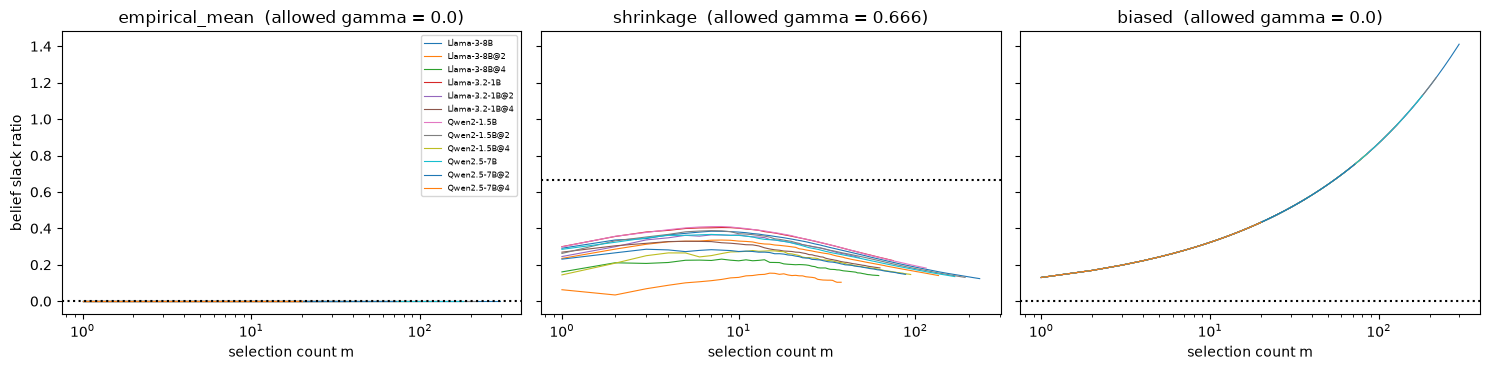

In [27]:
# Belief slack |e_i - c_hat_i| / rho_c(m) at each provider's m-th selection, one line per provider.
# The bid at the (m+1)-st win is the estimate formed after the m-th, so it is compared with the
# empirical mean of the first m costs; the platform's radius allows a ratio up to gamma.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (kind, (ep, radii)) in zip(axes, EST_EPISODES.items()):
    col = ep.log.columns()
    for name in ROSTER:
        mine = col["winner"] == name
        costs, bids = col["cost"][mine], col["bid_winner"][mine]
        k = np.arange(1, len(costs))
        c_hat = np.cumsum(costs)[:-1] / k
        rho_c = radii.c_max * np.array([radii.beta(int(i)) for i in k])
        ax.plot(k, np.abs(bids[1:] - c_hat) / rho_c, lw=0.8, label=name)
    ax.axhline(radii.gamma, color="k", ls=":")
    ax.set_xscale("log")
    ax.set_xlabel("selection count m")
    ax.set_title(f"{kind}  (allowed gamma = {radii.gamma})")
axes[0].set_ylabel("belief slack ratio")
axes[0].legend(fontsize=6)
plt.tight_layout()
plt.show()

## 22. Cumulative regret against the paper's bounds

Every arm's regret path from one episode, with both branches of each theorem's bound. The bounds hold for the mechanism on the good event; the other arms are shown against them for scale.

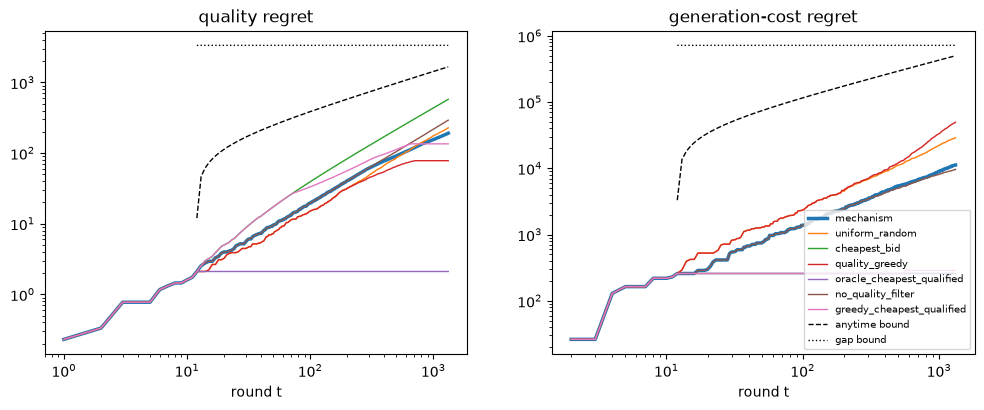

In [28]:
from cri.metrics import cumulative_series

paths = {}
for name in POLICIES:
    ep = simulate_episode(
        DATA,
        ROSTER,
        theta=THETA,
        radii=RADII,
        estimator=EstimatorConfig("empirical_mean"),
        margin=MARGIN,
        t_max=DATA.n_questions,
        seed=0,
        policy=make_policy(name, TRUTH),
        payment_rule=make_payment_rule("critical" if name in PAYMENT_APPLIES else None),
    )
    paths[name] = cumulative_series(ep.log, TRUTH, RADII)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, key, bounds_keys, title in [
    (axes[0], "quality_regret", ("quality_anytime", "quality_gap"), "quality regret"),
    (
        axes[1],
        "generation_regret",
        ("generation_anytime", "generation_gap"),
        "generation-cost regret",
    ),
]:
    for name in POLICIES:
        ax.plot(
            paths[name]["t"],
            np.where(paths[name][key] > 0, paths[name][key], np.nan),
            lw=2.5 if name == "mechanism" else 1,
            label=name,
        )
    ax.plot(
        paths["mechanism"]["t"],
        paths["mechanism"][bounds_keys[0]],
        "--",
        color="k",
        lw=1,
        label="anytime bound",
    )
    ax.plot(
        paths["mechanism"]["t"],
        paths["mechanism"][bounds_keys[1]],
        ":",
        color="k",
        lw=1,
        label="gap bound",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("round t")
    ax.set_title(title)
axes[1].legend(fontsize=7, loc="lower right")
plt.show()

## 23. Sweep the threshold

Move $\Theta$ and see who is qualified, who $i^*$ is, and what each policy does. A threshold must leave at least two qualified providers.

In [29]:
for theta in (0.40, THETA, 0.90):
    truth = ground_truth(DATA, ROSTER, theta, MARGIN)
    line = f"Theta = {theta:<6} |Q| = {len(truth.qualified)}  i* = {truth.istar:16}"
    for name in ("mechanism", "greedy_cheapest_qualified", "cheapest_bid"):
        ep = simulate_episode(
            DATA,
            ROSTER,
            theta=theta,
            radii=RADII,
            estimator=EstimatorConfig("empirical_mean"),
            margin=MARGIN,
            t_max=DATA.n_questions,
            seed=0,
            policy=make_policy(name, truth),
            payment_rule=None,
        )
        m = evaluate(ep.log, truth, RADII)
        line += f'   {name.split("_")[0]}: i* share {m.istar_share:.3f}, acc {m.realized_accuracy:.3f}'
    print(line)

Theta = 0.4    |Q| = 11  i* = Qwen2-1.5B         mechanism: i* share 0.169, acc 0.582   greedy: i* share 0.005, acc 0.371   cheapest: i* share 0.005, acc 0.371
Theta = 0.805  |Q| = 3  i* = Qwen2.5-7B         mechanism: i* share 0.138, acc 0.673   greedy: i* share 0.512, acc 0.748   cheapest: i* share 0.001, acc 0.371
Theta = 0.9    |Q| = 3  i* = Qwen2.5-7B         mechanism: i* share 0.367, acc 0.748   greedy: i* share 0.752, acc 0.826   cheapest: i* share 0.001, acc 0.371


## 24. Sweep the ceiling

The radius is proportional to $C_{max}$, so a higher ceiling means slower exploration for everyone. $C_{max}$ may not go below the roster's validity floor (the largest cost any provider can realize).

In [30]:
from cri.pricing import c_max_floor

print(
    f"validity floor for this roster: {c_max_floor(ROSTER, CONFIG.mechanism.token_cap, margin=MARGIN):.1f}"
)
CEILING_EPISODES = {}
for c_max in (RADII.c_max, 2 * RADII.c_max, 4 * RADII.c_max):
    radii = replace(RADII, c_max=c_max)
    ep = simulate_episode(
        DATA,
        ROSTER,
        theta=THETA,
        radii=radii,
        estimator=EstimatorConfig("empirical_mean"),
        margin=MARGIN,
        t_max=DATA.n_questions,
        seed=0,
    )
    CEILING_EPISODES[c_max] = ep
    m = evaluate(ep.log, TRUTH, radii)
    print(
        f"C_max = {c_max:6.0f}:  rho(100) = {radii.rho(100):6.1f}   i* share {m.istar_share:.3f}   accuracy {m.realized_accuracy:.3f}   cost {m.total_cost:,.0f}"
    )

validity floor for this roster: 240.0
C_max =    300:  rho(100) =   86.4   i* share 0.138   accuracy 0.673   cost 48,500
C_max =    600:  rho(100) =  172.7   i* share 0.133   accuracy 0.677   cost 56,769
C_max =   1200:  rho(100) =  345.5   i* share 0.105   accuracy 0.684   cost 61,234


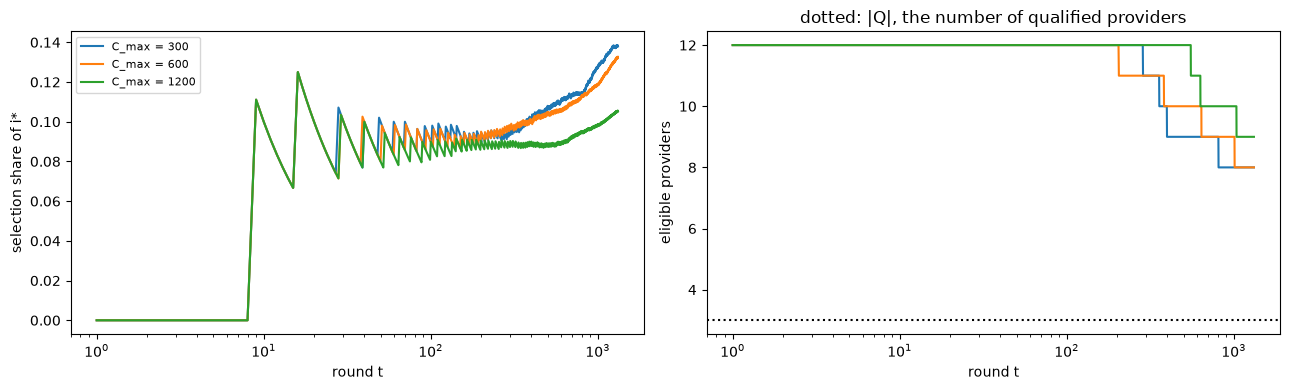

In [31]:
# A larger ceiling widens every radius: unqualified providers stay eligible longer and i* is found later.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for c_max, ep in CEILING_EPISODES.items():
    col = ep.log.columns()
    t = col["t"].astype(float)
    ax1.plot(
        t, np.cumsum(col["winner"] == TRUTH.istar) / t, label=f"C_max = {c_max:.0f}"
    )
    ax2.plot(t, col["n_eligible"], label=f"C_max = {c_max:.0f}")
ax1.set_xscale("log")
ax1.set_xlabel("round t")
ax1.set_ylabel("selection share of i*")
ax1.legend(fontsize=8)
ax2.axhline(len(TRUTH.qualified), color="k", ls=":")
ax2.set_xscale("log")
ax2.set_xlabel("round t")
ax2.set_ylabel("eligible providers")
ax2.set_title("dotted: |Q|, the number of qualified providers")
plt.tight_layout()
plt.show()

## 25. Write a run to disk

The scripted pipeline does the same grid at scale and stores everything: `run_experiment` writes a run directory, `read_episodes` reads it back, and `scripts/make_report.py` turns it into tables and figures.

In [32]:
import tempfile
from cri.config import override
from cri.experiment import run_experiment
from cri.results import read_episodes

small = override(
    CONFIG,
    name="demo",
    repetitions=2,
    environments=["GSM8K-ladder"],
    policies=["mechanism", "cheapest_bid"],
)
small = replace(small, output_dir=Path(tempfile.mkdtemp()))
paths = run_experiment(small)
print("written to", paths.root, "->", sorted(p.name for p in paths.root.iterdir()))
for rec in read_episodes(paths):
    print(
        f"  {rec['policy']:14} repetition {rec['repetition']}   i* share {rec['istar_share']:.3f}   accuracy {rec['realized_accuracy']:.3f}"
    )
print("\nthen:  python scripts/make_report.py", paths.root)

written to /tmp/tmp32kjns6a/runs/demo-20260904T081632Z -> ['checkpoints', 'episodes.jsonl', 'manifest.json', 'provider_states', 'rounds']
  mechanism      repetition 0   i* share 0.130   accuracy 0.680
  mechanism      repetition 1   i* share 0.121   accuracy 0.672
  cheapest_bid   repetition 0   i* share 0.001   accuracy 0.374
  cheapest_bid   repetition 1   i* share 0.001   accuracy 0.363

then:  python scripts/make_report.py /tmp/tmp32kjns6a/runs/demo-20260904T081632Z


## 26. Robustness to the threshold: a twelve-provider ladder

Four base models span the landscape, each served at N = 1, 2, and 4. As $\Theta$ rises across the grid, the qualified set shrinks from eleven providers to three. Because one pass leaves the radii wider than the cost gaps, this section compares finite-horizon behaviour rather than convergence.

Greedy policies can depend strongly on early cost draws. Their results change with $\Theta$, especially when the cheapest provider is unqualified and slow to eliminate. The mechanism continues to explore eligible providers, trading average selection share for more stable performance across thresholds.


In [33]:
LADDER = CONFIG.rosters["ladder"]
LADDER_ARMS = [
    "mechanism",
    "greedy_cheapest_qualified",
    "cheapest_bid",
    "uniform_random",
    "oracle_cheapest_qualified",
]
LADDER_REPS = 20
RADII_L = Radii(
    n=len(LADDER),
    delta=CONFIG.mechanism.delta,
    c_max=pinned_c_max(LADDER, CONFIG.mechanism.token_cap),
    gamma=CONFIG.mechanism.gamma,
)

qualities = sorted(
    expected_quality(DATA.records[parse_variant(m).base], parse_variant(m).n)
    for m in LADDER
)
# A grid over the ladder's quality range, keeping away from the qualities themselves.
THETAS = [0.39, 0.43, 0.50, 0.56, 0.60, 0.63, 0.66, 0.69, 0.75, 0.80, 0.85, 0.90]
print("qualities:", [round(x, 3) for x in qualities])
print(
    f"n = {len(LADDER)}, C_max = {RADII_L.c_max:.0f}, rho after 100 selections = {RADII_L.rho(100):.0f}\n"
)

# sweep[theta][arm]: metrics per repetition; collapses[theta][arm]: whether the episode's
# most-selected provider was unqualified and took more than half the rounds;
# logs[theta][arm]: repetition 0's log.
truths, sweep, collapses, logs = {}, {}, {}, {}
print(
    f'{"Theta":>7} {"|Q|":>3} {"i*":14}   i* share:  '
    + "  ".join(f'{name.split("_")[0]:>9}' for name in LADDER_ARMS)
)
for theta in THETAS:
    truths[theta] = ground_truth(DATA, LADDER, theta, MARGIN)
    sweep[theta] = {name: [] for name in LADDER_ARMS}
    collapses[theta] = {name: [] for name in LADDER_ARMS}
    logs[theta] = {}
    for rep in range(LADDER_REPS):
        for name in LADDER_ARMS:
            ep = simulate_episode(
                DATA,
                LADDER,
                theta=theta,
                radii=RADII_L,
                estimator=EstimatorConfig("empirical_mean"),
                margin=MARGIN,
                t_max=DATA.n_questions,
                seed=rep,
                repetition=rep,
                policy=make_policy(name, truths[theta]),
                payment_rule=make_payment_rule(
                    "critical" if name in PAYMENT_APPLIES else None
                ),
            )
            m = evaluate(ep.log, truths[theta], RADII_L)
            top = max(m.selection_counts, key=m.selection_counts.get)
            sweep[theta][name].append(m)
            collapses[theta][name].append(
                m.selection_counts[top] > DATA.n_questions / 2
                and top not in truths[theta].qualified
            )
            if rep == 0:
                logs[theta][name] = ep.log.columns()
    print(
        f"{theta:7.4f} {len(truths[theta].qualified):3d} {truths[theta].istar:14}              "
        + "  ".join(
            f"{np.mean([m.istar_share for m in sweep[theta][name]]):9.3f}"
            for name in LADDER_ARMS
        )
    )

qualities: [0.364, 0.41, 0.44, 0.574, 0.65, 0.652, 0.669, 0.677, 0.703, 0.907, 0.923, 0.93]
n = 12, C_max = 300, rho after 100 selections = 86

  Theta |Q| i*               i* share:  mechanism     greedy   cheapest    uniform     oracle
 0.3900  11 Qwen2-1.5B                      0.169      0.616      0.616      0.082      0.992
 0.4300  10 Qwen2-1.5B                      0.169      0.616      0.616      0.082      0.992
 0.5000   9 Qwen2-1.5B                      0.171      0.823      0.616      0.082      0.992
 0.5600   9 Qwen2-1.5B                      0.175      0.911      0.616      0.082      0.992
 0.6000   8 Llama-3-8B                      0.142      0.047      0.001      0.084      0.992
 0.6300   8 Llama-3-8B                      0.147      0.002      0.001      0.084      0.992
 0.6600   6 Qwen2.5-7B                      0.105      0.002      0.001      0.084      0.992
 0.6900   4 Qwen2.5-7B                      0.108      0.001      0.001      0.084      0.992
 0.7500   

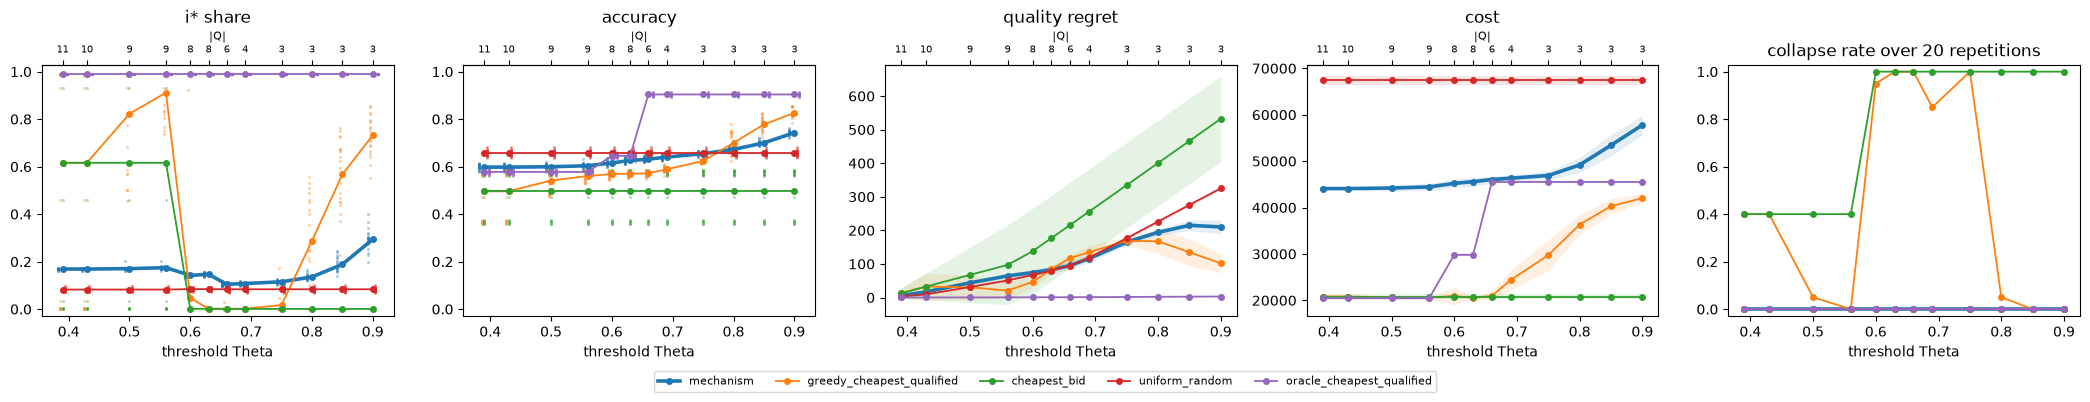

In [34]:
KEYS = [
    ("istar_share", "i* share"),
    ("realized_accuracy", "accuracy"),
    ("quality_regret", "quality regret"),
    ("total_cost", "cost"),
]
fig, axes = plt.subplots(1, 5, figsize=(21, 3.8))
for ax, (key, title) in zip(axes, KEYS):
    for k, name in enumerate(LADDER_ARMS):
        per_theta = [[getattr(m, key) for m in sweep[t][name]] for t in THETAS]
        mean, sd = np.array([np.mean(v) for v in per_theta]), np.array(
            [np.std(v) for v in per_theta]
        )
        (line,) = ax.plot(
            THETAS,
            mean,
            marker="o",
            ms=4,
            lw=2.6 if name == "mechanism" else 1.3,
            label=name,
        )
        if key not in ("istar_share", "realized_accuracy"):
            ax.fill_between(
                THETAS, mean - sd, mean + sd, color=line.get_color(), alpha=0.12, lw=0
            )
        else:
            # Every episode as a dot, arms offset slightly so clusters do not hide each other;
            # a bimodal arm shows as two clusters, which a mean and a band would hide.
            ax.scatter(
                [t + (k - 2) * 0.004 for t, v in zip(THETAS, per_theta) for _ in v],
                [x for v in per_theta for x in v],
                s=5,
                color=line.get_color(),
                alpha=0.35,
                lw=0,
            )
    if key in ("istar_share", "realized_accuracy"):
        ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("threshold Theta")
    ax.set_title(title)
    top = ax.secondary_xaxis("top")
    top.set_xticks(THETAS)
    top.set_xticklabels([str(len(truths[t].qualified)) for t in THETAS], fontsize=7)
    top.set_xlabel("|Q|", fontsize=8)

# Collapse rate: the share of episodes that ended on an unqualified provider.
ax = axes[4]
for name in LADDER_ARMS:
    ax.plot(
        THETAS,
        [np.mean(collapses[t][name]) for t in THETAS],
        marker="o",
        ms=4,
        lw=2.6 if name == "mechanism" else 1.3,
        label=name,
    )
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("threshold Theta")
ax.set_title(f"collapse rate over {LADDER_REPS} repetitions")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncols=5,
    fontsize=8,
    bbox_to_anchor=(0.5, -0.06),
)
plt.tight_layout()
plt.show()

In [35]:
# Worst case over Theta, and how often an arm collapsed onto an unqualified provider (over every episode).
print(
    f'{"arm":26} {"i* share (min .. max)":>22} {"accuracy":>16} {"cost":>20}   collapsed episodes'
)
summary = {}
for name in LADDER_ARMS:
    share = np.array([np.mean([m.istar_share for m in sweep[t][name]]) for t in THETAS])
    acc = np.array(
        [np.mean([m.realized_accuracy for m in sweep[t][name]]) for t in THETAS]
    )
    cost = np.array([np.mean([m.total_cost for m in sweep[t][name]]) for t in THETAS])
    collapsed = sum(sum(collapses[t][name]) for t in THETAS)
    summary[name] = (share, acc, cost, collapsed)
    print(
        f"{name:26} {share.min():8.3f} .. {share.max():8.3f} {acc.min():7.3f} .. {acc.max():5.3f} {cost.min():9,.0f} .. {cost.max():8,.0f}   {collapsed}/{len(THETAS) * LADDER_REPS}"
    )

mech, greedy, cheap, uni = (
    summary[n]
    for n in (
        "mechanism",
        "greedy_cheapest_qualified",
        "cheapest_bid",
        "uniform_random",
    )
)
print(
    f"\nworst i* share over Theta:  mechanism {mech[0].min():.3f}   greedy {greedy[0].min():.3f}   cheapest bid {cheap[0].min():.3f}"
)
print(
    f"worst accuracy over Theta:  mechanism {mech[1].min():.3f}   greedy {greedy[1].min():.3f}   cheapest bid {cheap[1].min():.3f}   uniform {uni[1].min():.3f}"
)
print(
    f"cost against uniform random: lower at {int(np.sum(mech[2] < uni[2]))}/{len(THETAS)} thresholds, {1 - mech[2].mean() / uni[2].mean():.0%} lower on average"
)

arm                         i* share (min .. max)         accuracy                 cost   collapsed episodes
mechanism                     0.105 ..    0.294   0.598 .. 0.743    44,087 ..   57,793   0/240
greedy_cheapest_qualified     0.001 ..    0.911   0.496 .. 0.826    20,518 ..   42,028   114/240
cheapest_bid                  0.001 ..    0.616   0.496 .. 0.496    20,830 ..   20,830   192/240
uniform_random                0.082 ..    0.084   0.659 .. 0.659    67,434 ..   67,434   0/240
oracle_cheapest_qualified     0.992 ..    0.992   0.578 .. 0.904    20,468 ..   45,509   0/240

worst i* share over Theta:  mechanism 0.105   greedy 0.001   cheapest bid 0.001
worst accuracy over Theta:  mechanism 0.598   greedy 0.496   cheapest bid 0.496   uniform 0.659
cost against uniform random: lower at 12/12 thresholds, 30% lower on average


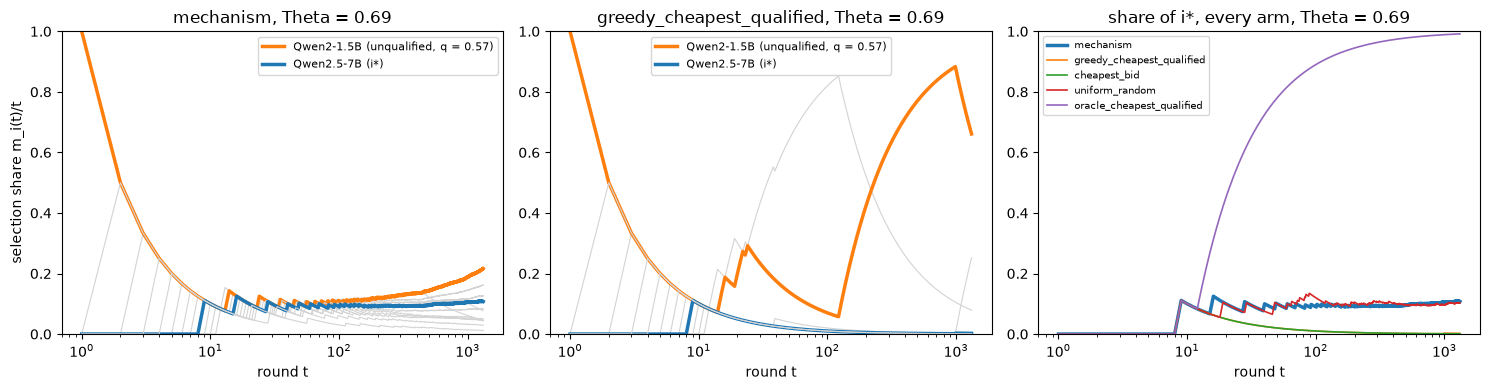

Theta = 0.69: |Q| = 4, i* = Qwen2.5-7B, cheapest overall = Qwen2-1.5B (q = 0.574)


In [36]:
# The threshold with the highest greedy collapse rate: selection share by round (repetition 0).
theta_c = min(
    THETAS,
    key=lambda t: np.mean(
        [m.istar_share for m in sweep[t]["greedy_cheapest_qualified"]]
    ),
)
truth_c = truths[theta_c]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes[:2], ("mechanism", "greedy_cheapest_qualified")):
    log_c = logs[theta_c][name]
    tt = log_c["t"].astype(float)
    counts = {m: int((log_c["winner"] == m).sum()) for m in LADDER}
    top = max(counts, key=counts.get)
    for m in LADDER:
        share = np.cumsum(log_c["winner"] == m) / tt
        if m == truth_c.istar:
            ax.plot(tt, share, color="tab:blue", lw=2.5, label=f"{m} (i*)")
        elif m == top and m not in truth_c.qualified:
            ax.plot(
                tt,
                share,
                color="tab:orange",
                lw=2.5,
                label=f"{m} (unqualified, q = {truth_c.q[m]:.2f})",
            )
        else:
            ax.plot(tt, share, color="lightgray", lw=0.8)
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel("round t")
    ax.set_title(f"{name}, Theta = {theta_c}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("selection share m_i(t)/t")
for name in LADDER_ARMS:
    log_c = logs[theta_c][name]
    axes[2].plot(
        log_c["t"],
        np.cumsum(log_c["winner"] == truth_c.istar) / log_c["t"],
        lw=2.5 if name == "mechanism" else 1.2,
        label=name,
    )
axes[2].set_xscale("log")
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("round t")
axes[2].set_title(f"share of i*, every arm, Theta = {theta_c}")
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()
print(
    f"Theta = {theta_c}: |Q| = {len(truth_c.qualified)}, i* = {truth_c.istar}, cheapest overall = {truth_c.cheapest_overall} (q = {truth_c.q[truth_c.cheapest_overall]:.3f})"
)